In [1]:
import sys
sys.path.append('../')
%reload_ext autoreload 
%autoreload 2

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bo

In [2]:
import json
import numpy as np

from predictor.classification_class import Classification
from predictor.resampling_class import Resampling
from predictor.cross_country_functions import *
from predictor.sri_lanka_functions import *
from explainer.callbacks import ExplainerCallback
from explainer.training_process_trajectories import TrajectorySummarizer

c:\Users\Andreas\projects\mimi-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#read the features
data_all = pd.read_csv('../data/lka/new_features_lka.csv', index_col=0)
data_all.index = data_all.index.astype(str)
data_all.rename(columns={'household_id': 'hhid'}, inplace=True)

In [4]:
#targets can be [ 'Zinc', 'VitaminA', 'Folate', 'VitaminB12', 'Iron', 'OverallInadequacy']
t = TargetTypeLKA.OverallInadequacy

In [5]:
y = target('../data/lka/ML_targets_lka.csv', t, 'lka_hies19')

In [6]:
y = prepare_target_classes(y, t)

In [7]:
y.index = y.index.astype(str)

In [8]:
y

,overall_mar
hhid,
11100111,1
11100121,0
11100131,1
11100141,1
11100151,1
...,...
19208551,1
19208561,1
19208571,1


In [9]:
data_all

,asset1,asset2,asset3,asset6,asset7,asset8,education2,food group1,food group2,food group3,...,housing1,housing2,housing4,labour1,labour4,labour5,r3q,rfh_avg,vim_avg,mean_entropy
household_id,,,,,,,,,,,,,,,,,,,,,
11108811,1.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,1.0,...,1.0,1.0,2.0,0.0,1.0,1.0,105.49575,80.47100,0.69605,5.853248
11108831,1.0,1.0,0.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,...,1.0,1.0,2.0,0.0,0.0,1.0,105.49575,80.47100,0.69605,5.853248
11108851,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,1.0,...,1.0,1.0,2.0,0.0,0.0,1.0,105.49575,80.47100,0.69605,5.853248
11108861,1.0,1.0,1.0,0.0,1.0,0.0,4.0,1.0,1.0,1.0,...,1.0,1.0,2.0,0.0,1.0,1.0,105.49575,80.47100,0.69605,5.853248
11108871,1.0,1.0,0.0,1.0,1.0,0.0,5.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,105.49575,80.47100,0.69605,5.853248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19208561,1.0,1.0,1.0,0.0,0.0,0.0,4.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,107.00645,72.04125,0.82635,5.455568
19208571,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,107.00645,72.04125,0.82635,5.455568
19208581,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,107.00645,72.04125,0.82635,5.455568


In [10]:
best_random_state = pd.read_csv('../data/results/perf_overall_mar_LKA_undersampling_0.1_xgboost.csv').best_random_state[0]

In [11]:
explain = ExplainerCallback(X_train=data_all, shap_sample_size=100)

In [12]:
classif_lka = Classification(y=y, 
                             data_all=data_all, 
                             type_target=t, 
                             device='cuda', 
                             random_state=best_random_state, 
                             cross_country=False, 
                             sampling='undersampling', 
                             sampling_strategy=0.5,
                             callbacks=[explain])

In [13]:
classif_lka.type_target

'overall_mar'

In [14]:
classif_lka.callbacks

In [15]:
model = classif_lka.xgbclassification_best_model('../data/results/besthyper_overall_mar_LKA_undersampling_0.1_xgboost.csv')

c:\Users\Andreas\projects\mimi-ml\paper_notebooks\..\predictor\classification_class.py:181: Warning: warning from our end: to use this function you first need to reset the random_state parameter of the classification class with the number that gives the best model performance after multiple trainings
  warnings.warn("warning from our end: to use this function you first need to reset the random_state parameter of the classification"


In [16]:
#model = classif_lka.xgbclassification_best_model('../data/results/besthyper_overall_mar_LKA_undersampling_0.1_xgboost.csv')

In [17]:
predictions = classif_lka.predictions(model)

In [18]:
performance_indicators = classif_lka.perf_ind_classification(predictions)

# Overall performance

In [19]:
threshold_probability = 0.5

#Generate dictionary for adjusted performance indicators
adjusted_performance_indicators = {}

#probalilities
y_proba = classif_lka.y_proba(model)

#---Performance---
if threshold_probability != None:
    predictions = predictions_proba(y_proba, threshold_probability)
else:
    predictions = classif_lka.predictions(model)

array_precision, array_recall, average_pre_recall = calculates_precision_recall_auc(y_proba, classif_lka, drop_intermediate=True)
#append average_pre_recall on performance_indicators
performance_indicators['average_pre_recall'] = average_pre_recall
array_fpr, array_tpr, rocauc_score = calculates_roc_auc(y_proba, classif_lka, drop_intermediate=True)
#append roc scores on performance_indicators
performance_indicators['rocauc_score'] = rocauc_score
#calculate adjusted precision-recall and roc values and save them on the adjusted_performance_indicators
adjusted_roc_auc, adjusted_average_pre_recall = get_adjusted_values(classif_lka, rocauc_score, average_pre_recall)
adjusted_performance_indicators['adjusted_rocauc'] = adjusted_roc_auc
adjusted_performance_indicators['adjusted_average_pre_recall'] = adjusted_average_pre_recall

### Variable importance:

get the shap values:

In [20]:
shap_values=classif_lka.shap_values(model)

convert code variable names to meaningful variable names by using lsms information:

In [21]:
explanations = pd.read_csv('../data/features_explanations.csv', index_col=0)
dict_all = explanations.set_index('codename')['explanation'].to_dict()

In [22]:
trainset = classif_lka.train_test['X_train']

In [23]:
trainset = replace_features_col_names(trainset, dict_all)

findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.
findfont: Font family 'Open sans' not found.


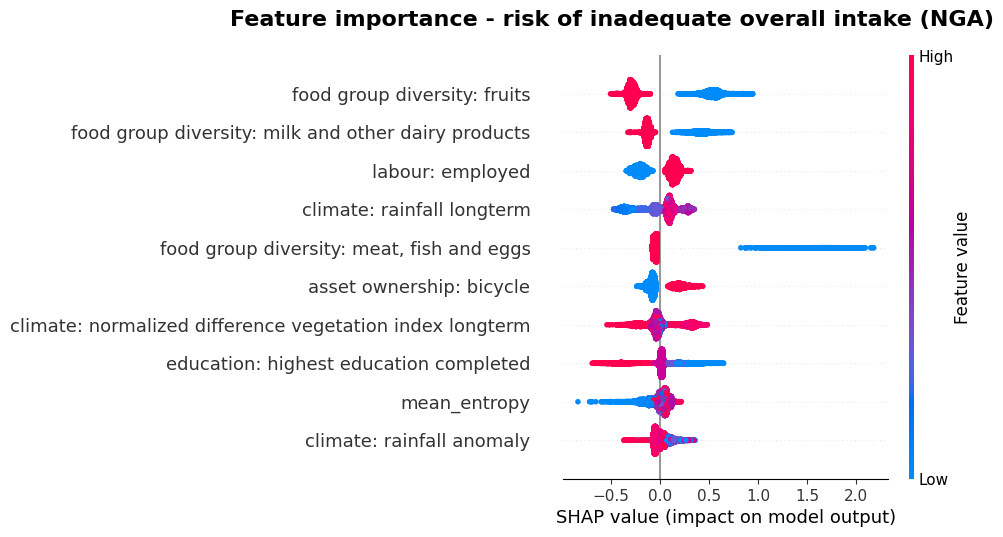

In [24]:
classif_lka.shap_summary_plot(model, trainset, title="Feature importance - risk of inadequate overall intake (NGA)", display=10, iso3='NGA', titlefontsize=16, save=False)

# SHAP trajectory

In [25]:
feature_names = [str(column) for column in classif_lka.train_test["X_train"].columns]

In [26]:
# SHAP trajectory dataframe: one row per iteration_episode, using mean SHAP value across all samples for simplicity now, will expand later (categorizing high and low values, etc.)
rows = []

for entry in explain.shap_values_history:  # full history
    iteration = int(entry["iteration"])
    shap_vals = entry["shap_values"]  

    step_df = pd.DataFrame(shap_vals, columns=feature_names)
    step_df["sample_idx"] = range(step_df.shape[0])
    step_df["iteration"] = iteration

    rows.append(
        pd.Series(
            step_df[feature_names].mean(axis=0),
            name=iteration
        )
    )

df_shap_traj = (
    pd.DataFrame(rows)
    .sort_index()
    .rename_axis("iteration")
    .reset_index()
)

df_shap_traj.head()


,iteration,asset1,asset2,asset3,asset6,asset7,asset8,education2,food group1,food group2,...,housing1,housing2,housing4,labour1,labour4,labour5,r3q,rfh_avg,vim_avg,mean_entropy
0,0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,-0.001016,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000977,0.000000,0.000000,0.000000,0.000000
1,20,0.000000,0.0,0.000000,-0.000343,0.000000,-0.004193,-0.014240,0.0,0.000000,...,0.0,0.0,-0.013862,0.0,0.0,0.008506,0.000148,0.005966,-0.005332,0.000739
2,40,-0.005720,0.0,0.000000,-0.002795,-0.001661,-0.010284,-0.025614,0.0,0.000000,...,0.0,0.0,-0.020418,0.0,0.0,0.018332,0.000477,0.021665,-0.012122,0.005063
3,60,-0.014465,0.0,0.000023,-0.004642,-0.002495,-0.016387,-0.030493,0.0,0.001707,...,0.0,0.0,-0.023703,0.0,0.0,0.024972,0.000911,0.038016,-0.015642,0.012764
4,80,-0.016389,0.0,0.000073,-0.015980,-0.002968,-0.019889,-0.035915,0.0,0.005192,...,0.0,0.0,-0.025804,0.0,0.0,0.030562,0.001753,0.041835,-0.026392,0.020694


<Axes: title={'center': 'Mean SHAP value trajectory over iterations'}, xlabel='iteration'>

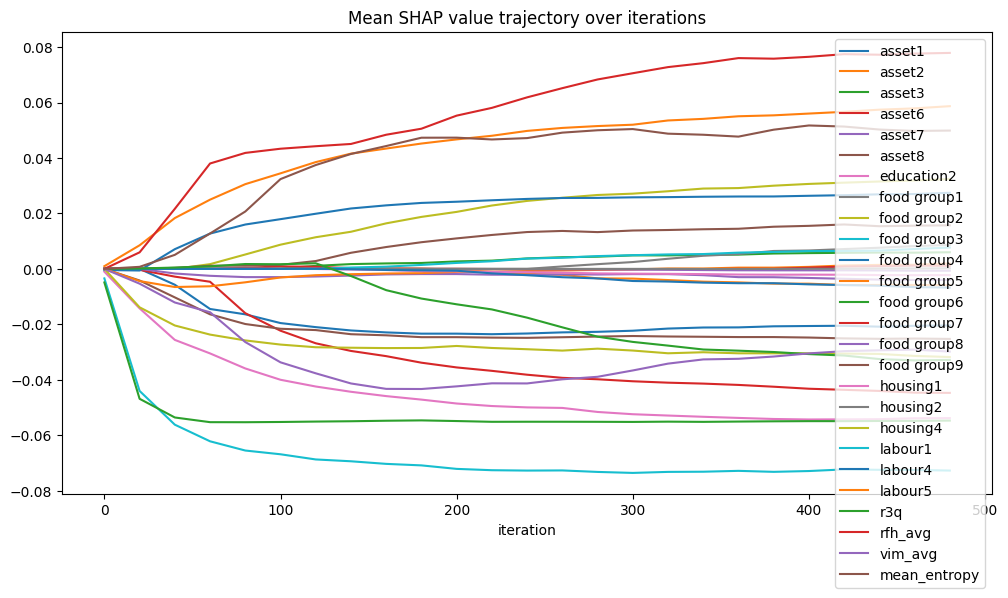

In [27]:
df_shap_traj.plot(x="iteration", y=feature_names, kind="line", figsize=(12, 6), title="Mean SHAP value trajectory over iterations")

In [28]:
ROUND_DECIMALS = 4
TOP_K_FEATURES = 12

def round_float(value):
    return round(float(value), ROUND_DECIMALS)

def summarize_progress(entry):
    shap_values = np.asarray(entry["shap_values"])

    if shap_values.ndim == 1:
        shap_values = shap_values.reshape(1, -1)

    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_signed = shap_values.mean(axis=0)
    top_feature_indexes = [
        int(index)
        for index in np.argsort(mean_abs)[::-1][:TOP_K_FEATURES]
        if mean_abs[index] > 0
    ]

    return {
        "i": int(entry["iteration"]),
        "b": round_float(np.asarray(entry["base_value"]).mean()),
        "m": round_float(mean_abs.sum()),
        "t": [
            [int(index), round_float(mean_abs[index]), round_float(mean_signed[index])]
            for index in top_feature_indexes
        ],
    }

feature_names = [str(column) for column in classif_lka.train_test["X_train"].columns]
progress = [summarize_progress(entry) for entry in explain.shap_values_history]

used_feature_indexes = sorted({item[0] for step in progress for item in step["t"]})
feature_lookup = [feature_names[index] for index in used_feature_indexes]
feature_index_map = {old_index: new_index for new_index, old_index in enumerate(used_feature_indexes)}

for step in progress:
    step["t"] = [
        [feature_index_map[index], mean_abs_value, mean_signed_value]
        for index, mean_abs_value, mean_signed_value in step["t"]
    ]

compact_shap_json = {
    "meta": {
        "f": feature_lookup,
        "k": TOP_K_FEATURES,
        "d": ROUND_DECIMALS,
        "n": int(np.asarray(explain.shap_values_history[0]["shap_values"]).shape[0]) if explain.shap_values_history else 0,
    },
    "p": progress,
}


In [29]:
with open('../data/results/trajectory_compact_overall_mar_LKA_undersampling_0.1_xgboost.json', 'w', encoding='utf-8') as fp:
    json.dump(compact_shap_json, fp, ensure_ascii=False, separators=(',', ':'))

# Tree structures

In [30]:
explain.trees

[{'iteration': 0,
  'tree': '  { "nodeid": 0, "depth": 0, "split": "food group6", "split_condition": 1, "yes": 1, "no": 2, "missing": 2 , "children": [\n    { "nodeid": 1, "depth": 1, "split": "food group4", "split_condition": 1, "yes": 3, "no": 4, "missing": 4 , "children": [\n      { "nodeid": 3, "leaf": 0.0678018555 }, \n      { "nodeid": 4, "depth": 2, "split": "labour5", "split_condition": 1, "yes": 7, "no": 8, "missing": 8 , "children": [\n        { "nodeid": 7, "leaf": 0.0120984977 }, \n        { "nodeid": 8, "leaf": 0.0319964699 }\n      ]}\n    ]}, \n    { "nodeid": 2, "depth": 1, "split": "food group3", "split_condition": 1, "yes": 5, "no": 6, "missing": 6 , "children": [\n      { "nodeid": 5, "depth": 2, "split": "food group4", "split_condition": 1, "yes": 9, "no": 10, "missing": 10 , "children": [\n        { "nodeid": 9, "leaf": 0.057692308 }, \n        { "nodeid": 10, "leaf": 0.00733212894 }\n      ]}, \n      { "nodeid": 6, "depth": 2, "split": "education2", "split_condit

In [31]:
summary_traj = TrajectorySummarizer(explain=explain, classification=classif_lka)
full_trajectory_json = summary_traj.summarize_training_process(country_iso='LKA', mn='overall_mar', save=True)

In [32]:
summary_traj.generate_tree_json(save=True)

{'feature_names': ['asset1',
  'asset2',
  'asset3',
  'asset6',
  'asset7',
  'asset8',
  'education2',
  'food group1',
  'food group2',
  'food group3',
  'food group4',
  'food group5',
  'food group6',
  'food group7',
  'food group8',
  'food group9',
  'housing1',
  'housing2',
  'housing4',
  'labour1',
  'labour4',
  'labour5',
  'r3q',
  'rfh_avg',
  'vim_avg',
  'mean_entropy'],
 'phase_summaries': [{'phase_name': 'early',
   'iteration_range': [0, 165],
   'top_phase_features': [{'feature_index': 24, 'split_count': 118},
    {'feature_index': 25, 'split_count': 88},
    {'feature_index': 10, 'split_count': 85},
    {'feature_index': 6, 'split_count': 78},
    {'feature_index': 23, 'split_count': 71}]},
  {'phase_name': 'mid',
   'iteration_range': [166, 332],
   'top_phase_features': [{'feature_index': 24, 'split_count': 112},
    {'feature_index': 22, 'split_count': 108},
    {'feature_index': 23, 'split_count': 98},
    {'feature_index': 6, 'split_count': 91},
    {'featu

In [33]:
summary_traj.generate_shap_json(save=True)

{'shap_sample_size': 100,
 'iteration_progress': [{'iteration': 0,
   'base_value': 0.693,
   'shap_magnitude': 0.0395,
   'top_shap_features': [{'feature_index': 12,
     'mean_abs_shap': 0.0219,
     'mean_signed_shap': -0.0049},
    {'feature_index': 9, 'mean_abs_shap': 0.0064, 'mean_signed_shap': -0.0034},
    {'feature_index': 6, 'mean_abs_shap': 0.0061, 'mean_signed_shap': -0.001},
    {'feature_index': 21, 'mean_abs_shap': 0.0027, 'mean_signed_shap': 0.001},
    {'feature_index': 10,
     'mean_abs_shap': 0.0024,
     'mean_signed_shap': -0.0004}]},
  {'iteration': 20,
   'base_value': 0.6917,
   'shap_magnitude': 0.5164,
   'top_shap_features': [{'feature_index': 12,
     'mean_abs_shap': 0.2618,
     'mean_signed_shap': -0.0469},
    {'feature_index': 9, 'mean_abs_shap': 0.0796, 'mean_signed_shap': -0.044},
    {'feature_index': 6, 'mean_abs_shap': 0.0457, 'mean_signed_shap': -0.0142},
    {'feature_index': 10, 'mean_abs_shap': 0.045, 'mean_signed_shap': -0.0006},
    {'featur